# LSTM — Airline Passengers Dataset
**Intuitive walkthrough with PyTorch**

Dataset: 144 months of international airline passenger counts (1949–1960)  
Task: given the last 12 months, predict the next month  
Goal: understand every step — data → model → train → predict

## Cell 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Cell 2 — Load the dataset

We use the built-in airline passengers data — one of the most famous time series datasets.  
It has 144 rows: one per month from January 1949 to December 1960.

In [ ]:
# Airline passengers data — hardcoded so no download needed
# Source: Box & Jenkins (1976), classic benchmark dataset
passengers = [
    112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104,  118,
    115, 126, 141, 135, 125, 149, 170, 170, 158, 133, 114,  140,
    145, 150, 178, 163, 172, 178, 199, 199, 184, 162, 146,  166,
    171, 180, 193, 181, 183, 218, 230, 242, 209, 191, 172,  194,
    196, 196, 236, 235, 229, 243, 264, 272, 237, 211, 180,  201,
    204, 188, 235, 227, 234, 264, 302, 293, 259, 229, 203,  229,
    242, 233, 267, 269, 270, 315, 364, 347, 312, 274, 237,  278,
    284, 277, 317, 313, 318, 374, 413, 405, 355, 306, 271,  306,
    315, 301, 356, 348, 355, 422, 465, 467, 404, 347, 305,  336,
    340, 318, 362, 348, 363, 435, 491, 505, 404, 359, 310,  337,
    360, 342, 406, 396, 420, 472, 548, 559, 463, 407, 362,  405,
    417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390,  432
]

# Build a proper DataFrame with a date index
dates = pd.date_range(start='1949-01', periods=144, freq='MS')
df = pd.DataFrame({'passengers': passengers}, index=dates)

print(df.head(12))  # First year
print(f'\nTotal months : {len(df)}')
print(f'Min          : {df.passengers.min()}')
print(f'Max          : {df.passengers.max()}')
print(f'Mean         : {df.passengers.mean():.1f}')

            passengers
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
1949-06-01         135
1949-07-01         148
1949-08-01         148
1949-09-01         136
1949-10-01         119
1949-11-01         104
1949-12-01         118

Total months : 144
Min          : 104
Max          : 622
Mean         : 280.3


## Cell 3 — Visualize the raw data

Before touching the model, always look at your data.  
You'll see two clear patterns:
- **Trend**: passenger count grows every year
- **Seasonality**: every July (summer) spikes — same pattern repeats annually

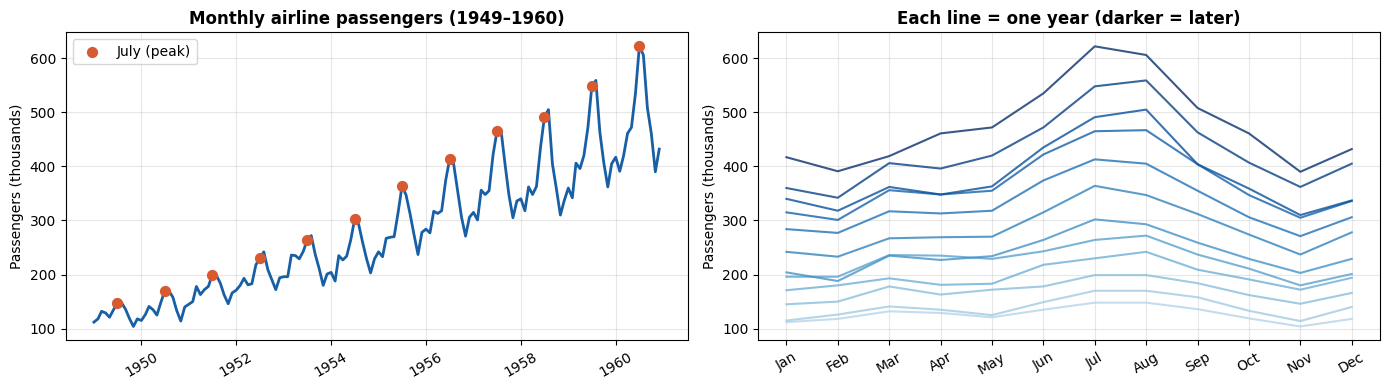

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full series
ax = axes[0]
ax.plot(df.index, df.passengers, color='#185FA5', linewidth=2)
ax.set_title('Monthly airline passengers (1949–1960)', fontweight='bold')
ax.set_ylabel('Passengers (thousands)')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=30)

# Annotate July peaks
july_df = df[df.index.month == 7]
ax.scatter(july_df.index, july_df.passengers,
           color='#D85A30', s=50, zorder=5, label='July (peak)')
ax.legend()

# Right: year-over-year comparison (each line = one year)
ax = axes[1]
colors = plt.cm.Blues(np.linspace(0.3, 1.0, 12))
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

for i, year in enumerate(range(1949, 1961)):
    year_data = df[df.index.year == year].passengers.values
    ax.plot(month_names, year_data,
            color=colors[i], linewidth=1.5, alpha=0.8,
            label=str(year))

ax.set_title('Each line = one year (darker = later)', fontweight='bold')
ax.set_ylabel('Passengers (thousands)')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('01_raw_data.png', dpi=130, bbox_inches='tight')
plt.show()

# The right chart makes the pattern very obvious:
# same seasonal shape every year, but lifted higher each time

## Cell 4 — Normalize the data

**Why normalize?**  
LSTM uses sigmoid and tanh activations — both squeeze values between 0 and 1 (or -1 and 1).  
Raw passenger counts go up to 622. Feeding 622 into a sigmoid gives ≈1.0 — no gradient flows.  
Scaling to [0, 1] keeps all values in the "active" region of the activation functions.

**Important**: fit the scaler ONLY on training data, then transform test data with the same scaler.  
Fitting on all data leaks future information into training — that's cheating.

In [4]:
# Train/test split — use first 80% for training
TRAIN_SIZE = int(len(df) * 0.80)   # 115 months train, 29 months test

train_raw = df.passengers.values[:TRAIN_SIZE].reshape(-1, 1).astype(float)
test_raw  = df.passengers.values[TRAIN_SIZE:].reshape(-1, 1).astype(float)

print(f'Train months : {len(train_raw)}  ({df.index[0].strftime("%b %Y")} — {df.index[TRAIN_SIZE-1].strftime("%b %Y")})')
print(f'Test months  : {len(test_raw)}   ({df.index[TRAIN_SIZE].strftime("%b %Y")} — {df.index[-1].strftime("%b %Y")})')

# Fit scaler on train ONLY
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw).flatten()
test_scaled  = scaler.transform(test_raw).flatten()     # transform, not fit_transform

print(f'\nTrain range before scaling : {train_raw.min():.0f} — {train_raw.max():.0f}')
print(f'Train range after scaling  : {train_scaled.min():.4f} — {train_scaled.max():.4f}')

Train months : 115  (Jan 1949 — Jul 1958)
Test months  : 29   (Aug 1958 — Dec 1960)

Train range before scaling : 104 — 491
Train range after scaling  : 0.0000 — 1.0000


## Cell 5 — Create sequences (sliding window)

**The core idea**: LSTM doesn't take the full time series at once.  
We slice it into overlapping windows:

```
Window size = 12  (one full year of context)

X[0] = [Jan,Feb,Mar,...,Dec 1949]  →  y[0] = Jan 1950
X[1] = [Feb,Mar,Apr,...,Jan 1950]  →  y[1] = Feb 1950
X[2] = [Mar,Apr,May,...,Feb 1950]  →  y[2] = Mar 1950
...
```

Window size = 12 is a natural choice here because the seasonality period IS 12 months.  
The model can see a full year of history and learn "after a July spike, August dips".

In [5]:
SEQ_LEN = 12   # 12 months of context to predict the next month

def make_sequences(data, seq_len):
    """
    Convert a 1D array into (X, y) pairs using a sliding window.

    data    : 1D numpy array of normalized values
    seq_len : number of past timesteps to use as input

    Returns:
        X : shape (n_samples, seq_len, 1)  — the input sequences
        y : shape (n_samples, 1)           — the target values
    """
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])      # 12 months in
        y.append(data[i + seq_len])          # month 13 = target
    X = np.array(X).reshape(-1, seq_len, 1)  # add feature dim
    y = np.array(y).reshape(-1, 1)
    return X, y


X_train, y_train = make_sequences(train_scaled, SEQ_LEN)
X_test,  y_test  = make_sequences(test_scaled,  SEQ_LEN)

print(f'X_train shape : {X_train.shape}   (samples, seq_len, features)')
print(f'y_train shape : {y_train.shape}   (samples, 1)')
print(f'X_test shape  : {X_test.shape}')
print(f'y_test shape  : {y_test.shape}')

# Print one example to make it concrete
print(f'\nExample — first training sequence:')
print(f'  Input  (12 months, normalized): {X_train[0].flatten().round(3)}')
print(f'  Target (month 13, normalized) : {y_train[0][0]:.4f}')
print(f'  Target (month 13, actual)     : {scaler.inverse_transform(y_train[0].reshape(-1,1))[0][0]:.0f} passengers')

X_train shape : (103, 12, 1)   (samples, seq_len, features)
y_train shape : (103, 1)   (samples, 1)
X_test shape  : (17, 12, 1)
y_test shape  : (17, 1)

Example — first training sequence:
  Input  (12 months, normalized): [0.021 0.036 0.072 0.065 0.044 0.08  0.114 0.114 0.083 0.039 0.    0.036]
  Target (month 13, normalized) : 0.0284
  Target (month 13, actual)     : 115 passengers


## Cell 6 — PyTorch Dataset and DataLoader

`Dataset` wraps our numpy arrays so PyTorch can index into them.  
`DataLoader` handles batching and shuffling automatically.

In [6]:
class AirlineDataset(Dataset):
    def __init__(self, X, y):
        # Convert numpy → float32 tensors (PyTorch default float type)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = AirlineDataset(X_train, y_train)
test_dataset  = AirlineDataset(X_test,  y_test)

# Batch size 16: with 103 train samples this gives ~7 batches per epoch
# shuffle=True for train — randomizes order each epoch so model doesn't overfit to sequence order
# shuffle=False for test — we want predictions in order for plotting
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

# Peek at one batch
X_batch, y_batch = next(iter(train_loader))
print(f'One batch — X shape: {X_batch.shape}, y shape: {y_batch.shape}')
print(f'  X dtype: {X_batch.dtype}')
print(f'  y dtype: {y_batch.dtype}')

One batch — X shape: torch.Size([16, 12, 1]), y shape: torch.Size([16, 1])
  X dtype: torch.float32
  y dtype: torch.float32


## Cell 7 — Build the LSTM model

```
Input shape : (batch, 12, 1)   — 12 timesteps, 1 feature (passenger count)
      ↓
  nn.LSTM    — hidden_size=64, num_layers=2
      ↓       takes the output of the LAST timestep only
  Linear(64 → 1)   — maps hidden state to a single predicted value
      ↓
Output shape: (batch, 1)       — predicted next month (normalized)
```

**Why `batch_first=True`?**  
By default PyTorch LSTM expects shape `(seq, batch, features)`.  
`batch_first=True` flips it to `(batch, seq, features)` which is more intuitive.

In [7]:
class AirlineLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # The LSTM layer
        # input_size = 1    (just the passenger count)
        # hidden_size = 64  (64 memory units — the cell state width)
        # num_layers = 2    (stacked: output of layer1 feeds into layer2)
        # dropout = 0.2     (applied between layers, helps prevent overfitting)
        # batch_first = True (input shape: batch, seq, features)
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout,
            batch_first = True
        )

        # Fully connected output layer
        # Takes the last hidden state (64 values) → predicts 1 number
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch_size, seq_len=12, input_size=1)

        # Initialize hidden state (h0) and cell state (c0) as zeros
        # Shape: (num_layers, batch_size, hidden_size)
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        # Run through LSTM
        # out shape    : (batch_size, seq_len, hidden_size) — output at each timestep
        # hn, cn shape : (num_layers, batch_size, hidden_size) — final hidden & cell states
        out, (hn, cn) = self.lstm(x, (h0, c0))

        # We only care about the LAST timestep's output
        # out[:, -1, :] grabs timestep 12 (the most recent) for every sample in the batch
        # Shape: (batch_size, hidden_size)
        last_out = out[:, -1, :]

        # Map to single prediction
        # Shape: (batch_size, 1)
        prediction = self.fc(last_out)
        return prediction


model = AirlineLSTM(
    input_size  = 1,
    hidden_size = 64,
    num_layers  = 2,
    dropout     = 0.2
).to(device)

print(model)
print(f'\nTotal parameters  : {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable params  : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

# Quick shape sanity check
dummy = torch.zeros(4, 12, 1).to(device)
out   = model(dummy)
print(f'\nShape check — input: {dummy.shape} → output: {out.shape}')

AirlineLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters  : 50,497
Trainable params  : 50,497

Shape check — input: torch.Size([4, 12, 1]) → output: torch.Size([4, 1])


## Cell 8 — Train the model

**Loss function**: MSELoss — mean squared error between predicted and actual normalized values.  
**Optimizer**: Adam — adaptive learning rate, works well for LSTMs out of the box.  
**Gradient clipping**: prevents exploding gradients (a common LSTM failure mode — without this,
gradients can grow exponentially during backprop-through-time and blow up the weights).

In [8]:
EPOCHS   = 150
LR       = 0.001

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()        # tells dropout/batchnorm layers to activate
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # 1. Zero out gradients from the previous step
        #    (PyTorch accumulates gradients by default — we must clear them)
        optimizer.zero_grad()

        # 2. Forward pass — compute prediction
        y_pred = model(X_batch)

        # 3. Compute loss
        loss = criterion(y_pred, y_batch)

        # 4. Backward pass — compute gradients
        loss.backward()

        # 5. Gradient clipping (max norm = 1.0)
        #    If the gradient vector norm > 1.0, scale it down to 1.0
        #    This prevents the "exploding gradient" problem in LSTMs
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 6. Update weights
        optimizer.step()

        epoch_loss += loss.item() * len(X_batch)

    avg_loss = epoch_loss / len(train_dataset)
    train_losses.append(avg_loss)

    if epoch % 25 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  |  Loss: {avg_loss:.6f}')

print('\nTraining complete.')

Epoch   1/150  |  Loss: 0.227359
Epoch  25/150  |  Loss: 0.010837
Epoch  50/150  |  Loss: 0.009880
Epoch  75/150  |  Loss: 0.007904
Epoch 100/150  |  Loss: 0.008533
Epoch 125/150  |  Loss: 0.005722
Epoch 150/150  |  Loss: 0.005498

Training complete.


## Cell 9 — Plot the training loss

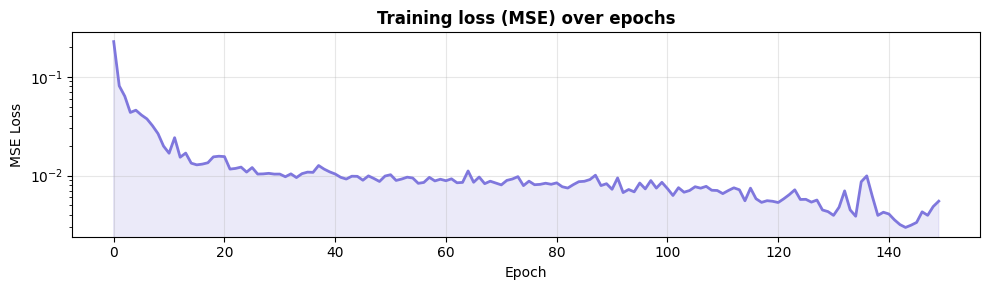

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(train_losses, color='#7F77DD', linewidth=2)
ax.fill_between(range(len(train_losses)), train_losses, alpha=0.15, color='#7F77DD')
ax.set_title('Training loss (MSE) over epochs', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_yscale('log')   # log scale makes the early fast drop more visible
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_loss.png', dpi=130, bbox_inches='tight')
plt.show()

# What to look for:
# - Loss should steadily decrease, then plateau
# - If it's still dropping sharply at epoch 150, train longer
# - If it bounces around, try a lower learning rate

## Cell 10 — Make predictions and denormalize

After training, we run the model in eval mode (disables dropout)  
and use `torch.no_grad()` to skip gradient computation (faster, less memory).

In [10]:
model.eval()  # disable dropout for inference

# ── Predict on train set ─────────────────────────────────────
train_preds = []
with torch.no_grad():
    for X_batch, _ in DataLoader(train_dataset, batch_size=64, shuffle=False):
        preds = model(X_batch.to(device)).cpu().numpy()
        train_preds.extend(preds.flatten())

# ── Predict on test set ──────────────────────────────────────
test_preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        preds = model(X_batch.to(device)).cpu().numpy()
        test_preds.extend(preds.flatten())

# ── Denormalize: scale back to actual passenger counts ───────
train_preds_actual = scaler.inverse_transform(
    np.array(train_preds).reshape(-1, 1)
).flatten()

test_preds_actual = scaler.inverse_transform(
    np.array(test_preds).reshape(-1, 1)
).flatten()

train_actual = scaler.inverse_transform(y_train).flatten()
test_actual  = scaler.inverse_transform(y_test).flatten()

# Quick metrics
train_mae = np.mean(np.abs(train_actual - train_preds_actual))
test_mae  = np.mean(np.abs(test_actual  - test_preds_actual))
test_mape = np.mean(np.abs((test_actual - test_preds_actual) / test_actual)) * 100

print(f'Train MAE : {train_mae:.1f} passengers')
print(f'Test  MAE : {test_mae:.1f} passengers')
print(f'Test  MAPE: {test_mape:.2f}%')

Train MAE : 14.9 passengers
Test  MAE : 76.0 passengers
Test  MAPE: 15.70%


## Cell 11 — Visualize predictions vs actual

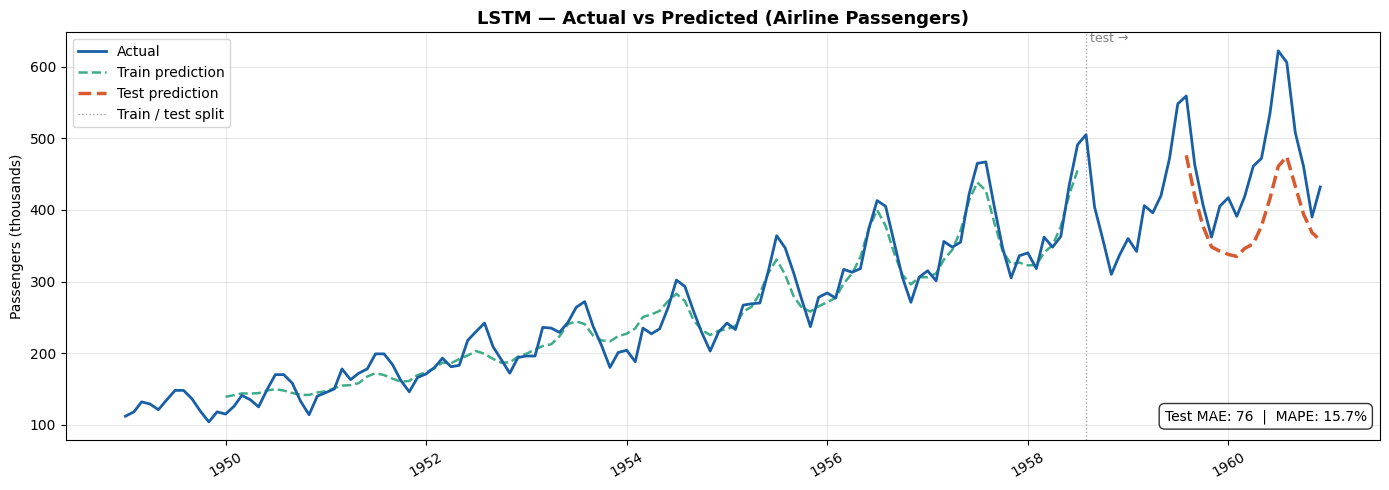

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

# Full actual series
ax.plot(df.index, df.passengers,
        color='#185FA5', linewidth=2, label='Actual', zorder=3)

# Train predictions
# Predictions start at index SEQ_LEN (first window ends there)
train_pred_dates = df.index[SEQ_LEN : SEQ_LEN + len(train_preds_actual)]
ax.plot(train_pred_dates, train_preds_actual,
        color='#1D9E75', linewidth=1.8, linestyle='--',
        label='Train prediction', alpha=0.85)

# Test predictions
test_start_idx   = TRAIN_SIZE + SEQ_LEN
test_pred_dates  = df.index[test_start_idx : test_start_idx + len(test_preds_actual)]
ax.plot(test_pred_dates, test_preds_actual,
        color='#D85A30', linewidth=2.5, linestyle='--',
        label='Test prediction', zorder=4)

# Mark the train/test boundary
split_date = df.index[TRAIN_SIZE]
ax.axvline(split_date, color='gray', linewidth=1,
           linestyle=':', alpha=0.7, label='Train / test split')
ax.text(split_date, df.passengers.max() * 1.02,
        ' test →', fontsize=9, color='gray')

ax.set_title('LSTM — Actual vs Predicted (Airline Passengers)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Passengers (thousands)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=30)

# Metrics box
ax.text(0.99, 0.05,
        f'Test MAE: {test_mae:.0f}  |  MAPE: {test_mape:.1f}%',
        transform=ax.transAxes, fontsize=10, ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('03_predictions.png', dpi=130, bbox_inches='tight')
plt.show()

## Cell 12 — Forecast the next 12 months

**Autoregressive forecasting**: we don't have future actual values,  
so we feed each prediction back as the next input.

```
Step 1: window = [last 12 known months]  →  predict month 145
Step 2: window = [last 11 known + pred 145]  →  predict month 146
Step 3: window = [last 10 known + pred 145, 146]  →  predict month 147
...and so on
```

Note: errors compound — the further out you forecast, the less reliable it becomes.

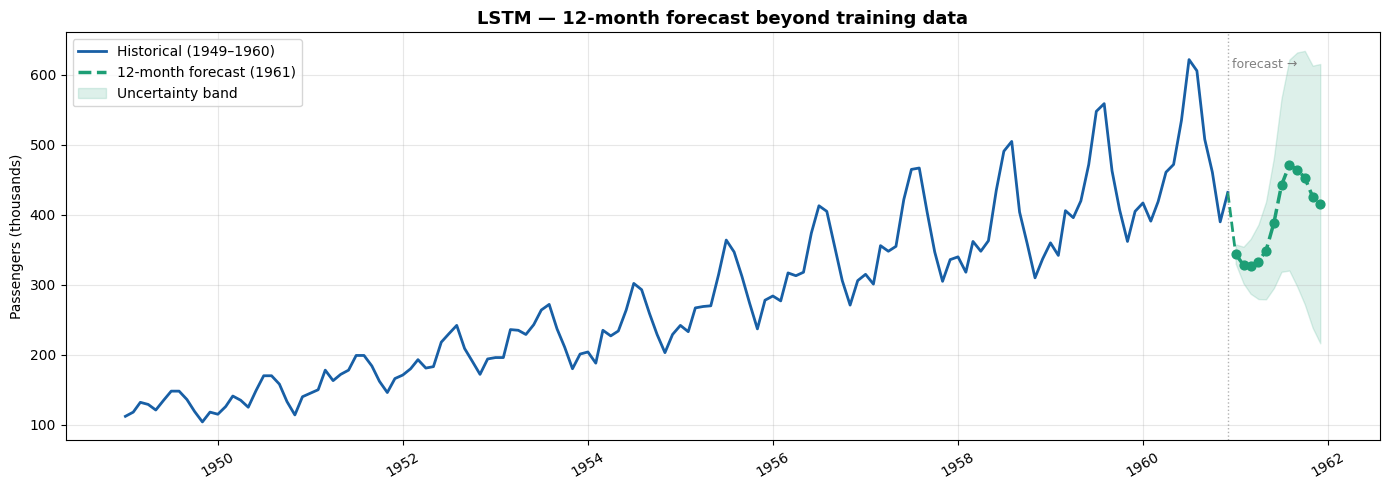


12-month forecast:
  Jan 1961 : 344 passengers
  Feb 1961 : 328 passengers
  Mar 1961 : 326 passengers
  Apr 1961 : 333 passengers
  May 1961 : 349 passengers
  Jun 1961 : 389 passengers
  Jul 1961 : 442 passengers
  Aug 1961 : 471 passengers
  Sep 1961 : 465 passengers
  Oct 1961 : 453 passengers
  Nov 1961 : 426 passengers
  Dec 1961 : 416 passengers


In [12]:
model.eval()

# Seed the window with the last SEQ_LEN known scaled values
all_scaled = scaler.transform(df.passengers.values.reshape(-1, 1)).flatten()
window = list(all_scaled[-SEQ_LEN:])   # last 12 months

future_preds = []
FORECAST_MONTHS = 12

with torch.no_grad():
    for _ in range(FORECAST_MONTHS):
        # Build input tensor from current window
        x = torch.tensor(window[-SEQ_LEN:],
                         dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
        # Shape: (1, 12, 1) — batch of 1

        pred = model(x).item()           # get scalar
        future_preds.append(pred)        # save
        window.append(pred)              # feed back into window

# Denormalize
future_actual = scaler.inverse_transform(
    np.array(future_preds).reshape(-1, 1)
).flatten()

# Build future dates (1961)
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=FORECAST_MONTHS, freq='MS'
)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

# Historical data
ax.plot(df.index, df.passengers,
        color='#185FA5', linewidth=2, label='Historical (1949–1960)')

# Forecast
# Connect last historical point to first forecast point
bridge_dates  = [df.index[-1], future_dates[0]]
bridge_values = [df.passengers.iloc[-1], future_actual[0]]
ax.plot(bridge_dates, bridge_values,
        color='#1D9E75', linewidth=2, linestyle='--')
ax.plot(future_dates, future_actual,
        color='#1D9E75', linewidth=2.5, linestyle='--',
        label='12-month forecast (1961)')
ax.scatter(future_dates, future_actual,
           color='#1D9E75', s=40, zorder=5)

# Uncertainty band (±8% heuristic — gets wider with horizon)
spread = np.array([0.04 * (i+1) for i in range(FORECAST_MONTHS)])
ax.fill_between(future_dates,
                future_actual * (1 - spread),
                future_actual * (1 + spread),
                alpha=0.15, color='#1D9E75', label='Uncertainty band')

ax.axvline(df.index[-1], color='gray', linewidth=1,
           linestyle=':', alpha=0.6)
ax.text(df.index[-1], df.passengers.max() * 0.98,
        ' forecast →', fontsize=9, color='gray')

ax.set_title('LSTM — 12-month forecast beyond training data',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('04_forecast.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n12-month forecast:')
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
for i, (d, p) in enumerate(zip(future_dates, future_actual)):
    print(f'  {month_names[i]} 1961 : {p:.0f} passengers')

## Cell 13 — What did the model actually learn?

Plot residuals (actual − predicted) to understand where the model struggles.

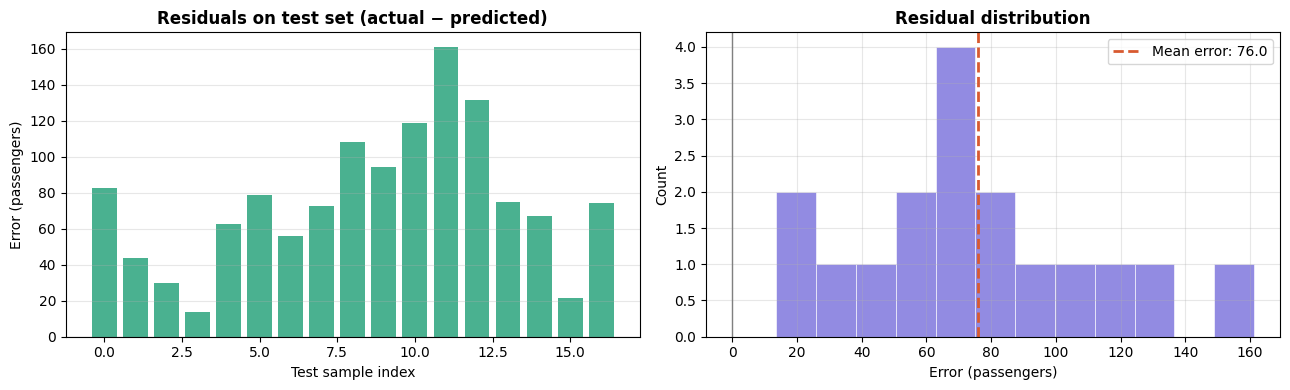

In [13]:
residuals = test_actual - test_preds_actual

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: residuals over time
ax = axes[0]
ax.bar(range(len(residuals)), residuals,
       color=np.where(residuals >= 0, '#1D9E75', '#D85A30'),
       alpha=0.8)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title('Residuals on test set (actual − predicted)', fontweight='bold')
ax.set_xlabel('Test sample index')
ax.set_ylabel('Error (passengers)')
ax.grid(True, alpha=0.3, axis='y')

# Right: residual distribution
ax = axes[1]
ax.hist(residuals, bins=12, color='#7F77DD',
        edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(0, color='gray', linewidth=1)
ax.axvline(residuals.mean(), color='#D85A30', linewidth=2,
           linestyle='--', label=f'Mean error: {residuals.mean():.1f}')
ax.set_title('Residual distribution', fontweight='bold')
ax.set_xlabel('Error (passengers)')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_residuals.png', dpi=130, bbox_inches='tight')
plt.show()

# If residuals cluster around 0 with no pattern — the model learned well
# If there's a pattern (e.g. always underpredicts in summer) — model is missing something

## Cell 14 — Experiment: what happens if SEQ_LEN = 3 instead of 12?

This is the key intuition experiment.  
With SEQ_LEN=3, the model only sees 3 months back — it can't see a full year,  
so it can't learn the seasonal pattern. Compare the test MAE.

In [14]:
results = {}

for seq_len in [3, 6, 12, 24]:
    # Rebuild sequences with this window size
    X_tr, y_tr = make_sequences(train_scaled, seq_len)
    X_te, y_te = make_sequences(test_scaled,  seq_len)

    tr_ds = AirlineDataset(X_tr, y_tr)
    te_ds = AirlineDataset(X_te, y_te)
    tr_ld = DataLoader(tr_ds, batch_size=16, shuffle=True)

    # Fresh model
    m = AirlineLSTM(input_size=1, hidden_size=64,
                    num_layers=2, dropout=0.2).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    # Train for 100 epochs
    for epoch in range(100):
        m.train()
        for X_b, y_b in tr_ld:
            X_b, y_b = X_b.to(device), y_b.to(device)
            opt.zero_grad()
            loss = loss_fn(m(X_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()

    # Evaluate
    m.eval()
    preds = []
    with torch.no_grad():
        for X_b, _ in DataLoader(te_ds, batch_size=64):
            preds.extend(m(X_b.to(device)).cpu().numpy().flatten())

    preds_act  = scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
    actual_act = scaler.inverse_transform(y_te).flatten()
    mae = np.mean(np.abs(actual_act - preds_act))
    results[seq_len] = mae
    print(f'SEQ_LEN={seq_len:2d}  |  Test MAE: {mae:.1f} passengers')

print('\nConclusion: SEQ_LEN=12 should win because the seasonality is 12 months.')
print('Shorter windows miss the annual pattern; longer windows add noise but little gain.')

SEQ_LEN= 3  |  Test MAE: 49.4 passengers
SEQ_LEN= 6  |  Test MAE: 53.1 passengers
SEQ_LEN=12  |  Test MAE: 66.8 passengers
SEQ_LEN=24  |  Test MAE: 94.0 passengers

Conclusion: SEQ_LEN=12 should win because the seasonality is 12 months.
Shorter windows miss the annual pattern; longer windows add noise but little gain.


## Cell 15 — Save the trained model

In [15]:
import pickle

torch.save(model.state_dict(), 'airline_lstm.pth')

with open('airline_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Model  saved: airline_lstm.pth')
print('Scaler saved: airline_scaler.pkl')

# To reload later:
#
#   loaded = AirlineLSTM(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
#   loaded.load_state_dict(torch.load('airline_lstm.pth', map_location='cpu'))
#   loaded.eval()
#
#   with open('airline_scaler.pkl', 'rb') as f:
#       scaler = pickle.load(f)

Model  saved: airline_lstm.pth
Scaler saved: airline_scaler.pkl


---
## Summary — what each piece does

| Step | What | Why |
|------|------|-----|
| MinMaxScaler | Scale to [0,1] | Keeps values in active range of sigmoid/tanh |
| make_sequences | Sliding window | Converts series → supervised (X, y) pairs |
| SEQ_LEN=12 | 12 months context | Matches the seasonality period |
| nn.LSTM | The memory cell | Learns trend + seasonality simultaneously |
| out[:, -1, :] | Last timestep only | Summary of all 12 months of context |
| clip_grad_norm_ | Gradient clipping | Prevents exploding gradients in BPTT |
| model.eval() + no_grad | Inference mode | Disables dropout, skips gradient tracking |
| scaler.inverse_transform | Denormalize | Converts predictions back to real passenger counts |

### Next things to try
- Add a second feature: `month_number` (1–12) as an explicit seasonal hint
- Try GRU: replace `nn.LSTM` with `nn.GRU` — fewer parameters, often similar results
- Try `hidden_size=32` vs `128` — does more capacity help with only 144 rows?
- Plot the gate activations to visualize what the forget gate is actually forgetting